# Movie Review Sentiment Analysis with Keras

This notebook demonstrates how to build a simple neural network to classify movie review sentiment (positive/negative) using the IMDb dataset with Keras. We will cover data loading, preprocessing, model definition, training, and evaluation, along with exploratory data analysis and explanations of key parameters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

In [2]:
import matplotlib.pyplot as plt


In [3]:
num_words = 1000
(x_train, y_train), (x_test,y_test) = imdb.load_data(num_words=num_words)
maxlen = 256

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Data Inspection: Shapes and Samples

In [4]:
import numpy as np

print("--- Dataset Shapes ---")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nNumber of training samples: {len(x_train)}")
print(f"Number of test samples: {len(x_test)}")
print(f"Max review length (after padding): {maxlen}")
print(f"Vocabulary size (num_words): {num_words}")

--- Dataset Shapes ---
x_train shape: (25000, 256)
y_train shape: (25000,)
x_test shape: (25000, 256)
y_test shape: (25000,)

Number of training samples: 25000
Number of test samples: 25000
Max review length (after padding): 256
Vocabulary size (num_words): 1000


### Raw Padded Review Data (Numerical)

In [5]:
print("--- Example Padded x_train reviews (first 5 rows) ---")
for i in range(5):
    print(f"Review {i}:\n{x_train[i]}\n")

print("--- Example Padded x_test reviews (first 2 rows) ---")
for i in range(2):
    print(f"Review {i}:\n{x_test[i]}\n")

--- Example Padded x_train reviews (first 5 rows) ---
Review 0:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   1  14  22  16  43 530 973   2   2  65 458   2  66   2   4 173
  36 256   5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4
 172 112 167   2 336 385  39   4 172   2   2  17 546  38  13 447   4 192
  50  16   6 147   2  19  14  22   4   2   2 469   4  22  71  87  12  16
  43 530  38  76  15  13   2   4  22  17 515  17  12  16 626  18   2   5
  62 386  12   8 316   8 106   5   4   2   2  16 480  66   2  33   4 130
  12  16  38 619   5  25 124  51  36 135  48  25   2  33   6  22  12 215
  28  77  52   5  14 407  16  82   2   8   4 107 117   2  15 256   4   2
   7   2   5 723  36  71  43 530 476  26 400 317  46   7   4   2   2  13
 104  88   4 381  15 297  98  32   2  56  26 141   6 194   2  18   4 226
  22  21 134 476  26 480   5 144  30   2  18  51  36  28 224

### Decoded Review Examples

In [7]:
print("--- Example Decoded Training Reviews ---")
for i in range(3):
    print(f"Review {i} (Label: {y_train[i]}):\n{decode_review(x_train[i])[:300]}...\n") # Print first 300 chars of decoded review

print("--- Example Decoded Test Reviews ---")
for i in range(2):
    print(f"Review {i} (Label: {y_test[i]}):\n{decode_review(x_test[i])[:300]}...\n") # Print first 300 chars of decoded review

--- Example Decoded Training Reviews ---


NameError: name 'decode_review' is not defined

### Explanation of `num_words`

When loading the IMDb dataset using `imdb.load_data(num_words=num_words)`, the `num_words` parameter specifies the maximum number of most frequent words to keep. Words are ranked by frequency, and only the `num_words` most common words are retained in the dataset. Less frequent words are discarded or replaced with a special 'out-of-vocabulary' token (usually index 2). This helps reduce the vocabulary size, making the model more manageable and preventing overfitting to rare words.

### Explanation of `maxlen`

`maxlen` (maximum length) is used in the `pad_sequences` function to standardize the length of all movie reviews. Since neural networks (especially those with fixed-size inputs like the `Embedding` layer followed by `GlobalAveragePooling1D` used here) require input sequences of the same length, reviews shorter than `maxlen` are padded with zeros, and reviews longer than `maxlen` are truncated. In this notebook, `maxlen` is set to 256.

### Explanation of `pad_sequences`

The `pad_sequences` function from `tensorflow.keras.preprocessing.sequence` is crucial for preparing the text data. It transforms a list of sequences (where each sequence is a list of integers representing words) into a 2D NumPy array. Each sequence in the array will have a uniform length specified by `maxlen`. Padding (adding zeros) or truncating occurs at either the beginning or end of the sequence. By default, padding and truncation happen at the beginning (`padding='pre'`, `truncating='pre'`), but can be changed to `post` if desired.

In [8]:
# Get the word index mapping
word_index = imdb.get_word_index()

# Create a reverse word index (mapping integers to words)
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# IMDb indices are offset by 3 for special tokens (padding, start of sequence, unknown)
def decode_review(text_sequence):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text_sequence])

# Display an example decoded review from x_train
print(f"Example decoded review (first 100 characters):\n{decode_review(x_train[0])[:100]}...")
print(f"Corresponding label: {y_train[0]} (0: negative, 1: positive)")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Example decoded review (first 100 characters):
? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? this film was just bri...
Corresponding label: 1 (0: negative, 1: positive)


In [9]:
model = keras.Sequential([
    layers.Input(shape = (maxlen,)),
    layers.Embedding(num_words, 64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1,activation='sigmoid')
])


model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 64)        │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,225 (266.50 KB)

 Trainable params: 68,225 (266.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs = 10, batch_size = 512, verbose=3)

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


In [11]:
loss,acc = model.evaluate(x_test,y_test, verbose=0)

loss, acc

(0.34538692235946655, 0.8463600277900696)

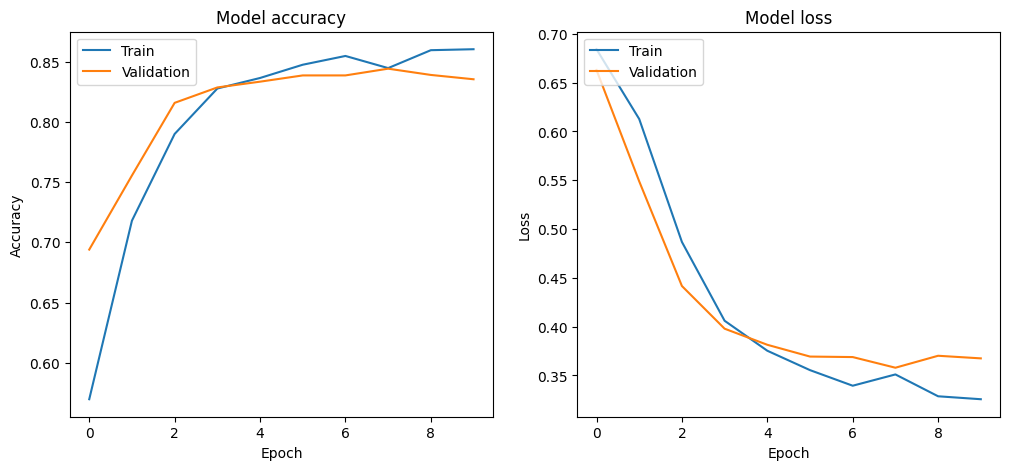

In [12]:


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()